# Set Up

(copied from SVM.ipynb)

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

pd.set_option('display.max_columns', None)



# Preprocessing

(copied from SVM.ipynb)

In [126]:
df = pd.read_csv('../Data/raw_data.csv', sep=';')

columns_to_drop = ['stem-root','veil-type', 'veil-color',  'stem-surface', 'spore-print-color']
df = df.drop(columns=columns_to_drop)
df.columns

Index(['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-color', 'has-ring', 'ring-type',
       'habitat', 'season'],
      dtype='object')

In [127]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

class KNNCategoricalImputer(BaseEstimator, TransformerMixin):
    """
    Supervised KNN imputer for one or more categorical columns.

    - Assumes input X is a pandas DataFrame with original columns.
    - For each target column:
        * uses all other columns that have no missing values as predictors
        * does its own StandardScaler + OneHotEncoder internally
    """

    def __init__(self, target_cols, num_cols=None, n_neighbors=5, weights="distance"):
        # allow a single string or a list
        if isinstance(target_cols, str):
            target_cols = [target_cols]

        self.target_cols = target_cols
        self.num_cols = num_cols   # list of numeric columns to scale
        self.n_neighbors = n_neighbors
        self.weights = weights

    def fit(self, X, y=None):
        df = X.copy()

        self.knn_models_ = {}
        self.feature_cols_ = {}

        for col in self.target_cols:
            # rows where the target is known
            mask = df[col].notna()

            # trainable columns: all except the target, and with no missing values on these rows
            _X_train_tmp = df.loc[mask].drop(columns=[col])
            train_columns = _X_train_tmp.columns[
                _X_train_tmp.isnull().sum() == 0
            ].tolist()

            X_train = df.loc[mask, train_columns]
            y_train = df.loc[mask, col]

            # numeric + categorical columns for THIS target
            if self.num_cols is None:
                # if not provided, infer numeric from dtypes
                num_cols = X_train.select_dtypes(include="number").columns.tolist()
            else:
                # keep only those num_cols that are actually in train_columns
                num_cols = [c for c in self.num_cols if c in train_columns]

            cat_cols = [c for c in train_columns if c not in num_cols + [col]]

            # preprocessor for KNN
            pre = ColumnTransformer(
                transformers=[
                    ("num", StandardScaler(), num_cols),
                    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
                ]
            )

            # KNN classifier pipeline
            clf = Pipeline(
                steps=[
                    ("pre", pre),
                    (
                        "knn",
                        KNeighborsClassifier(
                            n_neighbors=self.n_neighbors, weights=self.weights
                        ),
                    ),
                ]
            )

            # fit KNN for this target column
            clf.fit(X_train, y_train)

            # store model and the columns it expects
            self.knn_models_[col] = clf
            self.feature_cols_[col] = train_columns

        return self

    def transform(self, X):
        df = X.copy()

        for col in self.target_cols:
            mask_missing = df[col].isna()

            if mask_missing.any():
                feats = self.feature_cols_[col]
                X_missing = df.loc[mask_missing, feats]
                df.loc[mask_missing, col] = self.knn_models_[col].predict(X_missing)

        return df

In [128]:
from sklearn import set_config
from sklearn.preprocessing import LabelEncoder
set_config(transform_output="pandas")


X = df.drop(columns='class')
y = df['class']

# label encode y

le = LabelEncoder()
y = le.fit_transform(y)

numeric_features = X.select_dtypes(include='float64').columns.to_list()
categorical_features = X.select_dtypes(include='object').columns.to_list()

# Columns to impute
features_to_impute = ['cap-surface', 'gill-attachment', 'gill-spacing', 'ring-type']

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False  #
)


knn_imputer = KNNCategoricalImputer(
    target_cols=features_to_impute,
    num_cols=numeric_features
)


column_trans = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)


preprocess = Pipeline(steps=[
    ('knn_imputer', knn_imputer),      # impute missing values using KNN
    ('column_transformer', column_trans)
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


preprocess.fit(X_train)

X_train = preprocess.transform(X_train)
X_test = preprocess.transform(X_test)

X_train

,cap-diameter,stem-height,stem-width,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_d,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_b,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,does-bruise-or-bleed_f,does-bruise-or-bleed_t,gill-attachment_a,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_p,gill-attachment_s,gill-attachment_x,gill-spacing_c,gill-spacing_d,gill-spacing_f,gill-color_b,gill-color_e,gill-color_f,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-color_b,stem-color_e,stem-color_f,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,has-ring_f,has-ring_t,ring-type_e,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_p,ring-type_r,ring-type_z,habitat_d,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_a,season_s,season_u,season_w
36219,-0.195867,-0.104756,-0.639647,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
54188,0.039043,-0.801696,-0.439222,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1609,0.313735,1.253535,0.218893,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
20481,-0.616430,-0.736450,-0.574833,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
20546,-0.654319,-0.819490,-0.613722,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28217,0.012521,-0.629685,0.036415,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
51211,-0.455404,0.013872,-0.044353,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [129]:
y_train

array([0, 1, 1, ..., 1, 1, 0])

## Random Forest Classifier

Import needed libraries:

In [130]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Here, we fit a basic random forest classifier with the only hyperparameters with it being trained with 100 decision trees and a set random state.

In [142]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Evaluation

Use the classifier to predict the training and test set. Calculate the accuracy and other scores based on the predictions of the classifier.

In [152]:
y_pred = clf.predict(X_test)
y_pred_train = clf.predict(X_train)

test_accuracy = accuracy_score(y_test, y_pred)
train_accuracy = accuracy_score(y_train, y_pred_train)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=8))

Training Accuracy: 1.0000
Test Accuracy: 0.9999

Classification Report:
              precision    recall  f1-score   support

           0  1.00000000 0.99981604 0.99990801      5436
           1  0.99985249 1.00000000 0.99992624      6778

    accuracy                      0.99991813     12214
   macro avg  0.99992624 0.99990802 0.99991712     12214
weighted avg  0.99991814 0.99991813 0.99991813     12214



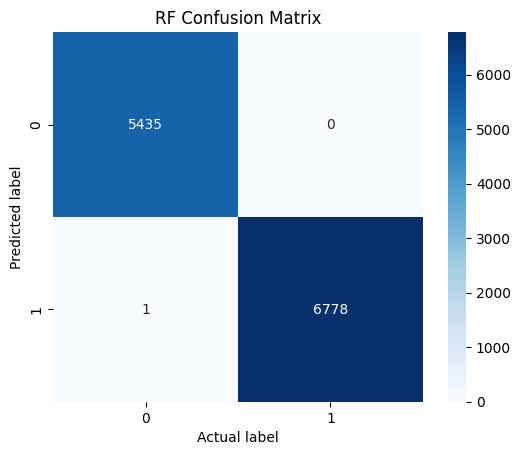

In [153]:
mat = confusion_matrix(y_test, y_pred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d',
            cmap='Blues')
plt.xlabel('Actual label')
plt.ylabel('Predicted label')
plt.title("RF Confusion Matrix");

### ROC Curve

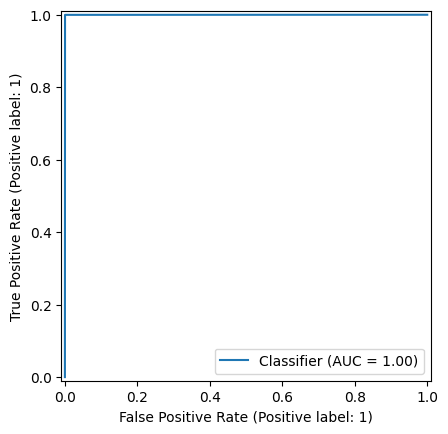

In [150]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_pred)

### Precision vs Recall Curve

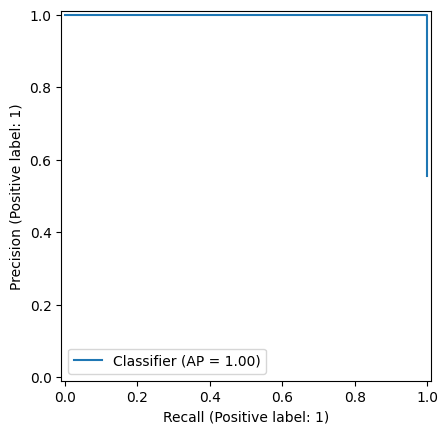

In [149]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, y_pred)

## Feature Importance

According to [this article](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html) on analyzing Random Forest feature importances, there are two ways to calculate the top important features: (1) Mean decrease in impurity (MDI), (2) Feature permutation.

Both ways will be shown here, although one thing to note is that MDI has a bias in high cardinality features (many unique values), thus feature permutation is usually more preferred.

### Mean Decrease in Impurity (MDI)

Calculating the MDI importance for each feature through the method within the classifier `feature_importances_`.

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# feature names AFTER preprocessing (one-hot columns included)
feature_names = X_train.columns
importances = clf.feature_importances_

Showing the top 15 important features within the dataset:

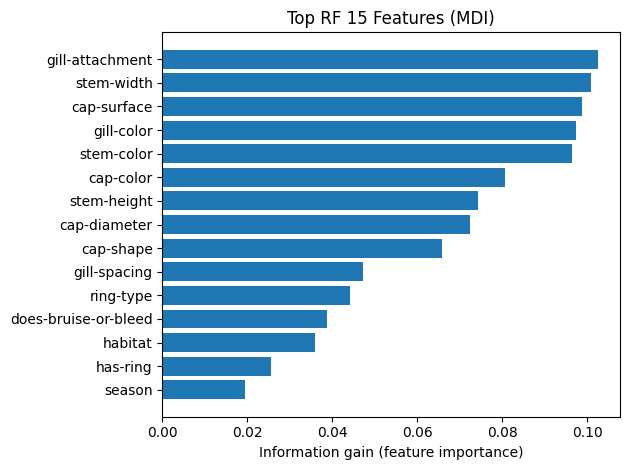

In [148]:
# Put into a DataFrame
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# For one-hot columns, sklearn names them like "cap-shape_flat", "cap-shape_convex", ...
# So we take everything before the first "_" as the original feature name
imp_df['orig_feature'] = imp_df['feature'].str.split('_', n=1).str[0]

# Sum importances over dummies belonging to the same original feature
agg = (
    imp_df
    .groupby('orig_feature', as_index=False)['importance']
    .sum()
)

# Sort for nicer plotting
agg = agg.sort_values('importance')

# Plot one bar per original feature
plt.title("Top RF 15 Features (MDI)")
plt.barh(agg['orig_feature'], agg['importance'])
plt.xlabel("Information gain (feature importance)")
plt.tight_layout()
plt.show()

### Feature Permutation

Calculating the permutation importance for each feature through the method `permutation_importance`.

In [144]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# feature names AFTER preprocessing (one-hot columns included)
feature_names = X_train.columns
importances = permutation_importance(
    clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

Showing the top 15 important features within the dataset:

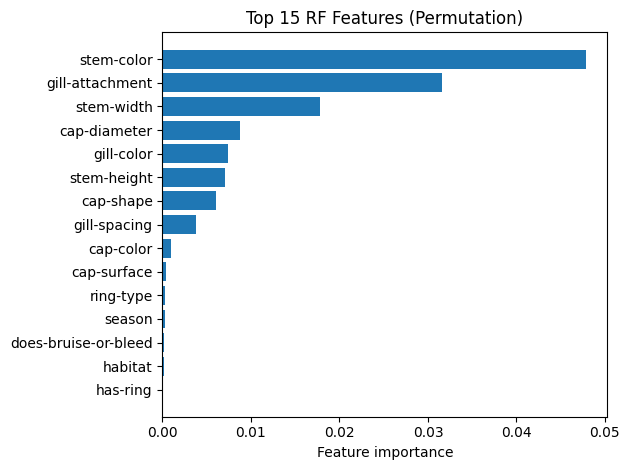

In [145]:
# Put into a DataFrame
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances.importances_mean
})

# For one-hot columns, sklearn names them like "cap-shape_flat", "cap-shape_convex", ...
# So we take everything before the first "_" as the original feature name
imp_df['orig_feature'] = imp_df['feature'].str.split('_', n=1).str[0]

# Sum importances over dummies belonging to the same original feature
agg = (
    imp_df
    .groupby('orig_feature', as_index=False)['importance']
    .sum()
)

# Sort for nicer plotting
agg = agg.sort_values('importance')

# Plot one bar per original feature
plt.title("Top 15 RF Features (Permutation)")
plt.barh(agg['orig_feature'], agg['importance'])
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()